In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
#  This is only for the use of Google Colab
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
y = np.loadtxt('/drive/MyDrive/COM3031/week3/Prussian-Horse-Kick-Data_Workshop.csv') # I used the Google Colab for this demonstration. You may the load the data locally.

$p(\mathbf{y}|\lambda) \propto \prod_{i=1}^n \lambda^{y_i} \exp(-\lambda) $<br>
$p(\mathbf{y}|\lambda) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda)$ <br>
$\log p(\mathbf{y}|\lambda) \propto \sum_{i=1}^n y_i \log(\lambda) -n\lambda $

In [ ]:
def likelihood(theta,*args):
    n = len(y)
    L = np.sum(y)*np.log(theta) - theta*n
    return -L

In [ ]:
bounds = [(0.0001,100)]
x0 = [1]
results = minimize(likelihood,x0,args = (y),bounds = bounds, method = 'L-BFGS-B')
print(len(y))

280


In [ ]:
print(results.x,results.fun)


[0.70000005] 265.9082890119921


Output()

Output()

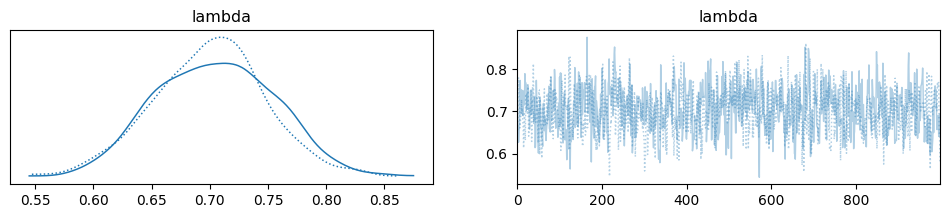

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,0.702,0.05,0.607,0.792,0.002,0.001,641.0,1264.0,1.0


In [ ]:
# Estimation of posterior using Markov Chain Monte Carlo
import pymc as pm # Importing the library
basic_model = pm.Model() #defining the model

with basic_model:
    lam = pm.Gamma('lambda',alpha=0.25,beta=0.5) # Prior on lambda
    Y_obs = pm.distributions.discrete.Poisson('Y',mu = lam,observed = y) #Likelihood
    trace = pm.sample(1000) # Calling the NUTS MCMC technique to estimate the posterior


pm.plot_trace(trace) #plotting the posterior distribution
plt.show()
pm.summary(trace)# printing the summary of the output

# Analytical approach
 As the gamma Prior is the conjugate prior for Poisson distribution, the posterior is also a Gamma distribution

# Likelihood
$p(\mathbf{y}|\lambda) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda)$ <br>
# Prior
$p(\lambda) \propto \lambda^{\alpha-1} \exp(-\beta \lambda)$ <br>
# Posterior
$p(\lambda|\mathbf{y}) \propto (\mathbf{y}|\lambda) p(\lambda)$ <br>
$p(\lambda|\mathbf{y}) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda) \lambda^{\alpha-1} \exp(-\beta \lambda)$ <br>
$p(\lambda|\mathbf{y}) \lambda^{\sum_{i=1}^ny_i+\alpha-1} \exp(-\lambda(\beta+n))$ <br>
$\lambda \sim \text{Gamma}(\sum_{i=1}^ny_i+\alpha,\beta+n)$


prior_mean =  0.5
prior_sigma = 1.0
posterior_mean= 0.6996434937611408
posterior_sigma= 0.04994269421077326


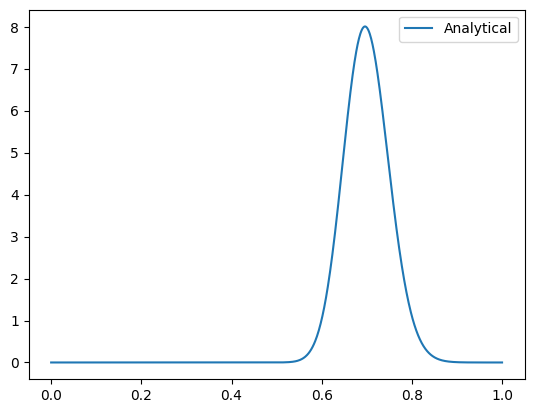

In [ ]:
# Prior parameters

# Weak prior
m = np.mean(y)
k = 1

# Strong prior
m = np.mean(y)
k = 1000

# Strong but conflicting prior
m = 0.2 #a small or large value
k = 1000

alpha = m * k
beta  = k

prior_mean = alpha/beta
prior_sigma = np.sqrt(alpha/beta**2)

print('prior_mean = ',prior_mean)
print('prior_sigma =', prior_sigma)

n = len(y)
# Posterior parameters
alpha_new = alpha + np.sum(y)
beta_new = beta + n
# Mean and standard deviation in Gamma distribution is: mean = alpha_new/beta_new and standard deviation = sqrt(alpha_new/beta_new^2)
mu_lambda = alpha_new/beta_new
sigma_lambda = np.sqrt(alpha_new/beta_new**2)
print('posterior_mean=', mu_lambda)
print('posterior_sigma=', sigma_lambda)

# plotting pdf of the posterior
import scipy
from scipy import stats
lam_samples = np.linspace(0,1,1000)
pdf_lambda = stats.gamma.pdf(lam_samples,alpha_new,scale=1/beta_new)
plt.plot(lam_samples,pdf_lambda,label='Analytical')
# plt.xlim(0.5,0.9)
plt.legend()
plt.show()